In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/archive (2).zip"
extract_path = "/content/drive/MyDrive/imagedataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

KeyboardInterrupt: 

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/imagedataset"))

['supermarket_product_thumbnails', 'clean_dataset', 'recommended_images', 'features.npy', 'valid_paths.npy', 'image_labels.npy', 'dataset_index.csv']


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails"))

['combined.csv', 'images.csv', 'jpg', 'metadata.csv', 'tokens.csv']


In [ ]:
import os

base_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg"

print("Total categories:", len(os.listdir(base_path)))

Total categories: 5812


In [ ]:
import os
import shutil

base_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg"
clean_path = "/content/drive/MyDrive/imagedataset/clean_dataset"

os.makedirs(clean_path, exist_ok=True)

kept = 0
removed = 0

for category in os.listdir(base_path):
    category_path = os.path.join(base_path, category)

    if os.path.isdir(category_path):
        # get only image files
        images = [f for f in os.listdir(category_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        if len(images) > 0:
            shutil.copytree(category_path, os.path.join(clean_path, category))
            kept += 1
        else:
            removed += 1

print("✅ Kept folders:", kept)
print("❌ Removed empty folders:", removed)

FileExistsError: [Errno 17] File exists: '/content/drive/MyDrive/imagedataset/clean_dataset/d6c6f4ea'

In [ ]:
print("Remaining categories:", len(os.listdir(clean_path)))

In [ ]:
import os

clean_path = "/content/drive/MyDrive/imagedataset/clean_dataset"

print("Exists:", os.path.exists(clean_path))

In [ ]:

import os


clean_path = "/content/drive/MyDrive/imagedataset/clean_dataset"


categories = os.listdir(clean_path)

print("Total categories:", len(categories))

Total categories: 5812


In [ ]:
image_counts = []

for category in categories:
    category_path = os.path.join(clean_path, category)

    if os.path.isdir(category_path):
        count = len(os.listdir(category_path))
        image_counts.append(count)

print("Total categories checked:", len(image_counts))

Total categories checked: 5812


In [ ]:
import numpy as np

print("Minimum images in a category:", np.min(image_counts))
print("Maximum images in a category:", np.max(image_counts))
print("Average images per category:", np.mean(image_counts))

In [ ]:
combined_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/combined.csv"

images_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/images.csv"

metadata_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/metadata.csv"

tokens_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/tokens.csv"

In [ ]:
import pandas as pd

combined = pd.read_csv(combined_path)
images = pd.read_csv(images_path)
metadata = pd.read_csv(metadata_path)
tokens = pd.read_csv(tokens_path)

print("Loaded successfully!")

EmptyDataError: No columns to parse from file

In [ ]:
print("TOKENS:")
print(tokens.head())

print("\nMETADATA:")
print(metadata.head())

print("\nCOMBINED:")
print(combined.head())

TOKENS:
  category_id                        category
0    100e10c0                         cheeses
1    10100008  Lightweight Volumizing Shampoo
2    104df089                     Elbow pasta
3    105af8b1         Acetaminophen Chewables
4    105ec579                   Sandwich Bags

METADATA:
  category_id        id  width  height
0    100e10c0  f40b49f1    150     150
1    10100008  26aa35e6    142     142
2    104df089  21b1eda9    118     118
3    105af8b1  12b15383    142     142
4    105af8b1  72203d5d    149     149

COMBINED:
  category_id        id                        category  \
0    100e10c0  f40b49f1                         cheeses   
1    10100008  26aa35e6  Lightweight Volumizing Shampoo   
2    104df089  21b1eda9                     Elbow pasta   
3    105af8b1  12b15383         Acetaminophen Chewables   
4    105af8b1  72203d5d         Acetaminophen Chewables   

                                               image  width  height  
0  /9j/4AAQSkZJRgABAQAAAQABAAD/2wCE

In [ ]:
# pick one image path
img_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg/d6cf5210/xyz.jpg"

# extract category_id
category_id = img_path.split("/")[-2]

# map to category name
category_name = tokens[tokens['category_id'] == category_id]['category'].values[0]

print("Category:", category_name)

Category: Laundry Detergent Pacs


In [ ]:
category_name = tokens[tokens['category_id'] == category_id]['category'].values[0]

In [ ]:
import pandas as pd
import os

base_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails"

metadata = pd.read_csv(base_path + "/metadata.csv")
tokens = pd.read_csv(base_path + "/tokens.csv")

In [ ]:
df = metadata.merge(tokens, on="category_id")

In [ ]:
import os
import pandas as pd

In [ ]:
dataset_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg"   # change this
token_csv_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/tokens.csv"
meta_csv_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/metadata.csv"

In [ ]:
tokens_df = pd.read_csv("/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/tokens.csv")
metadata_df = pd.read_csv("/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/metadata.csv")

print("TOKENS CSV")
print(tokens_df.head())

print("\nMETADATA CSV")
print(metadata_df.head())

TOKENS CSV
  category_id                        category
0    100e10c0                         cheeses
1    10100008  Lightweight Volumizing Shampoo
2    104df089                     Elbow pasta
3    105af8b1         Acetaminophen Chewables
4    105ec579                   Sandwich Bags

METADATA CSV
  category_id        id  width  height
0    100e10c0  f40b49f1    150     150
1    10100008  26aa35e6    142     142
2    104df089  21b1eda9    118     118
3    105af8b1  12b15383    142     142
4    105af8b1  72203d5d    149     149


In [ ]:
for folder in os.listdir("/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg"):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        images = os.listdir(folder_path)

        print("\n========================")
        print("FOLDER NAME:", folder)
        print("NO OF IMAGES:", len(images))
        print("SAMPLE IMAGES:", images[:5])

Streaming output truncated to the last 5000 lines.

FOLDER NAME: 5311aa63
NO OF IMAGES: 12
SAMPLE IMAGES: ['2add4f60.jpg', '372ee22.jpg', '5d270300.jpg', '7ca4f761.jpg', '7f96285d.jpg']

FOLDER NAME: 531617ac
NO OF IMAGES: 1
SAMPLE IMAGES: ['3e903783.jpg']

FOLDER NAME: 53227917
NO OF IMAGES: 1
SAMPLE IMAGES: ['53227917.jpg']

FOLDER NAME: 532a5e7b
NO OF IMAGES: 1
SAMPLE IMAGES: ['64a01072.jpg']

FOLDER NAME: 535edcd5
NO OF IMAGES: 6
SAMPLE IMAGES: ['11a6d944.jpg', '164fed4d.jpg', '308bc990.jpg', '601ccee6.jpg', 'd8ebb8d5.jpg']

FOLDER NAME: 5367b9e7
NO OF IMAGES: 1
SAMPLE IMAGES: ['39a6e1fd.jpg']

FOLDER NAME: 5387bd69
NO OF IMAGES: 1
SAMPLE IMAGES: ['c4128516.jpg']

FOLDER NAME: 5389cb7c
NO OF IMAGES: 1
SAMPLE IMAGES: ['11b0022d.jpg']

FOLDER NAME: 539c008e
NO OF IMAGES: 1
SAMPLE IMAGES: ['49b14137.jpg']

FOLDER NAME: 539c288f
NO OF IMAGES: 1
SAMPLE IMAGES: ['539c288f.jpg']

FOLDER NAME: 53aab22a
NO OF IMAGES: 1
SAMPLE IMAGES: ['46f54c47.jpg']

FOLDER NAME: 53b2cc0d
NO OF IMAGES: 1
S

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg"

total_folders = 0
total_images = 0

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        total_folders += 1
        total_images += len(os.listdir(folder_path))

print("Total folders:", total_folders)
print("Total images:", total_images)

Total folders: 5812
Total images: 15987


In [ ]:
import os
import pandas as pd

dataset_path =  "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg"

data = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        data.append(count)

df = pd.DataFrame(data, columns=["image_count"])

In [ ]:
print(df["image_count"].value_counts().sort_index())

image_count
1      4079
2       627
3       265
4       163
5       122
       ... 
87        1
89        1
93        1
99        1
106       1
Name: count, Length: 63, dtype: int64


In [ ]:
import os

dataset_path ="/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg"

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        for img in os.listdir(folder_path):
            print("Folder:", folder, "→ Image:", img)
        break  # remove this if you want full output

Folder: d6c6f4ea → Image: ea4b7367.jpg
Folder: d6c6f4ea → Image: f18e0ec8.jpg


In [ ]:
import pandas as pd

tokens = pd.read_csv("/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/tokens.csv")

id_to_name = dict(zip(tokens["category_id"], tokens["category"]))

In [ ]:
folder = "d6c6f4ea"

print("Category:", id_to_name.get(folder, "UNKNOWN"))

Category: paper towels


In [ ]:
dataset_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg"
token_csv_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/tokens.csv"
meta_csv_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/metadata.csv"

In [ ]:
import pandas as pd

tokens = pd.read_csv(token_csv_path)
metadata = pd.read_csv(meta_csv_path)

print(tokens.head())
print(metadata.head())

  category_id                        category
0    100e10c0                         cheeses
1    10100008  Lightweight Volumizing Shampoo
2    104df089                     Elbow pasta
3    105af8b1         Acetaminophen Chewables
4    105ec579                   Sandwich Bags
  category_id        id  width  height
0    100e10c0  f40b49f1    150     150
1    10100008  26aa35e6    142     142
2    104df089  21b1eda9    118     118
3    105af8b1  12b15383    142     142
4    105af8b1  72203d5d    149     149


In [ ]:
id_to_category = dict(zip(tokens["category_id"], tokens["category"]))

print("Sample mapping:", list(id_to_category.items())[:5])

Sample mapping: [('100e10c0', 'cheeses'), ('10100008', 'Lightweight Volumizing Shampoo'), ('104df089', 'Elbow pasta'), ('105af8b1', 'Acetaminophen Chewables'), ('105ec579', 'Sandwich Bags')]


In [ ]:
import os

data = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        label = id_to_category.get(folder)

        if label:  # only valid folders
            for img in os.listdir(folder_path):
                img_path = os.path.join(folder_path, img)

                data.append((img_path, label))

print("Total samples:", len(data))
print("Sample:", data[:5])

Total samples: 15987
Sample: [('/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg/d6c6f4ea/ea4b7367.jpg', 'paper towels'), ('/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg/d6c6f4ea/f18e0ec8.jpg', 'paper towels'), ('/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg/d6ca4dd/847dd70d.jpg', 'Refill Water'), ('/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg/d6cf5210/132cbab0.jpg', 'Laundry Detergent Pacs'), ('/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg/d6cf5210/2bf6660a.jpg', 'Laundry Detergent Pacs')]


In [ ]:
print("Total samples:", len(data))

Total samples: 15987


In [ ]:
df = pd.DataFrame(data, columns=["image_path", "label"])

print(df.head())
print(df["label"].value_counts().head())

                                          image_path                   label
0  /content/drive/MyDrive/imagedataset/supermarke...            paper towels
1  /content/drive/MyDrive/imagedataset/supermarke...            paper towels
2  /content/drive/MyDrive/imagedataset/supermarke...            Refill Water
3  /content/drive/MyDrive/imagedataset/supermarke...  Laundry Detergent Pacs
4  /content/drive/MyDrive/imagedataset/supermarke...  Laundry Detergent Pacs
label
Toothpaste         106
Eggs                99
Ice Cream           93
Sparkling Water     89
Potato Chips        87
Name: count, dtype: int64


In [ ]:
print("Total classes:", df["label"].nunique())
print(df["label"].value_counts())

Total classes: 5812
label
Toothpaste                                                           106
Eggs                                                                  99
Ice Cream                                                             93
Sparkling Water                                                       89
Potato Chips                                                          87
                                                                    ... 
Lucerne Butter Salted Sweet Cream 4 Quarters - 16 Oz - albertsons      1
Tortilla Strips                                                        1
measuring spoons and cups set                                          1
Anti Dandruff Shampoo and Conditioner                                  1
cannellini beans                                                       1
Name: count, Length: 5812, dtype: int64


In [ ]:
min_images = 5

valid_classes = df["label"].value_counts()
valid_classes = valid_classes[valid_classes >= min_images].index

df_clean = df[df["label"].isin(valid_classes)]

print("Before:", len(df))
print("After:", len(df_clean))
print("Classes left:", df_clean["label"].nunique())

Before: 15987
After: 9207
Classes left: 678


In [ ]:
df_clean = df[df["label"].isin(valid_classes)].copy()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_clean.loc[:, "label_encoded"] = le.fit_transform(df_clean["label"])

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_clean,
    test_size=0.2,
    stratify=df_clean["label_encoded"],
    random_state=42
)

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"].values, train_df["label_encoded"].values)
)

train_ds = train_ds.map(load_image)
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["image_path"].values, test_df["label_encoded"].values)
)

test_ds = test_ds.map(load_image)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=(224, 224, 3),
    weights="imagenet"
)

base_model.trainable = False  # freeze base model

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(le.classes_), activation="softmax")
])

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 678)            │       174,246 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,551,753 (17.36 MB)

 Trainable params: 502,182 (1.92 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 919s 4s/step - accuracy: 0.0081 - loss: 6.3897 - val_accuracy: 0.0114 - val_loss: 6.2263
Epoch 2/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 764s 3s/step - accuracy: 0.0087 - loss: 6.2726 - val_accuracy: 0.0109 - val_loss: 6.2163
Epoch 3/10
 86/231 ━━━━━━━━━━━━━━━━━━━━ 6:32 3s/step - accuracy: 0.0086 - loss: 6.2428

KeyboardInterrupt: 

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
model = EfficientNetB0(weights="imagenet", include_top=False, pooling="avg")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
dataset_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg"

image_paths = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        for img in os.listdir(folder_path):
            image_paths.append(os.path.join(folder_path, img))

print("Total images:", len(image_paths))

Total images: 15987


In [ ]:
def get_features(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.expand_dims(img, axis=0)
    img = preprocess_input(img)

    return model.predict(img, verbose=0).flatten()

In [ ]:
features = []
valid_paths = []

for i, path in enumerate(image_paths):
    try:
        feat = get_features(path)
        features.append(feat)
        valid_paths.append(path)

        if i % 500 == 0:
            print(f"Processed: {i}/{len(image_paths)}")

    except:
        continue  # skip corrupted images

features = np.array(features)

print("Final feature shape:", features.shape)

Final feature shape: (0,)


In [ ]:
import numpy as np

np.save("features.npy", features)
np.save("paths.npy", valid_paths)

print("Saved successfully!")

Saved successfully!


In [ ]:
features = np.load("features.npy")
valid_paths = np.load("paths.npy")

print("Loaded:", features.shape)

Loaded: (15987, 1280)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(features)

print("Similarity matrix ready:", similarity.shape)

Similarity matrix ready: (15987, 15987)


In [ ]:
def recommend(index, top_k=5):
    print("Query Image:", valid_paths[index])

    scores = list(enumerate(similarity[index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    print("\nTop similar products:\n")

    for i, score in scores[1:top_k+1]:
        print(valid_paths[i], "Score:", round(score, 3))

In [ ]:
recommend(0)

Query Image: /content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg/d6c6f4ea/ea4b7367.jpg

Top similar products:

/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg/4f7e2470/18445092.jpg Score: 0.998
/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg/4f7e2470/6cfb0ae8.jpg Score: 0.968
/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg/4f7e2470/eefd0b3c.jpg Score: 0.967
/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg/4f7e2470/7ef03f59.jpg Score: 0.951
/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg/4f7e2470/530301e2.jpg Score: 0.904


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving download.jpeg to download.jpeg


In [ ]:
import cv2

test_image_path = "download.jpeg"

img = cv2.imread(test_image_path)

print(img)

[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[253 253 253]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[251 251 251]
  [252 252 252]
  [254 254 254]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[250 250 250]
  [251 251 251]
  [252 252 252]
  ...
  [255 255 255]
  [254 254 254]
  [253 253 253]]]


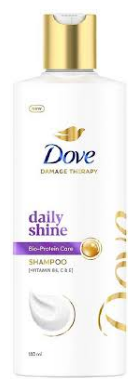

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
for file_name in uploaded.keys():
    test_image_path = file_name

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend(image_feature, top_k=5):

    # Step 1: compute similarity with ALL images
    scores = cosine_similarity([image_feature], features)[0]

    # Step 2: get top K indices
    top_indices = scores.argsort()[-top_k:][::-1]

    # Step 3: return multiple results
    results = []

    for i in top_indices:
        results.append((valid_paths[i], scores[i], image_labels[i]))

    return results

In [ ]:
test_feature = get_features("download.jpeg")

results = recommend(test_feature, top_k=5)

for path, score, label in results:
    print("Image:", path)
    print("Score:", score)
    print("Category:", label)
    print("------")

NameError: name 'image_labels' is not defined

In [ ]:
print(len(image_labels))
print(len(valid_paths))
print(len(features))

NameError: name 'image_labels' is not defined

In [ ]:
dataset_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg"
token_csv_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/tokens.csv"
meta_csv_path = "/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/metadata.csv"

In [ ]:
import pandas as pd
import os

tokens = pd.read_csv(token_csv_path)
meta = pd.read_csv(meta_csv_path)

df = meta.merge(tokens, on="category_id", how="left")

print(df.head())

  category_id        id  width  height                        category
0    100e10c0  f40b49f1    150     150                         cheeses
1    10100008  26aa35e6    142     142  Lightweight Volumizing Shampoo
2    104df089  21b1eda9    118     118                     Elbow pasta
3    105af8b1  12b15383    142     142         Acetaminophen Chewables
4    105af8b1  72203d5d    149     149         Acetaminophen Chewables


In [ ]:
image_to_category = dict(zip(df["id"], df["category"]))

In [ ]:
image_paths = []
image_labels = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        for img in os.listdir(folder_path):
            img_id = img.split(".")[0]

            if img_id in image_to_category:

                image_paths.append(os.path.join(folder_path, img))
                image_labels.append(image_to_category[img_id])

In [ ]:
import numpy as np

image_paths = np.array(image_paths)
image_labels = np.array(image_labels)
features = np.array(features)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend(image_feature, top_k=5):

    scores = cosine_similarity([image_feature], features)[0]

    top_indices = scores.argsort()[-top_k:][::-1]

    results = []

    for i in top_indices:
        results.append((image_paths[i], scores[i], image_labels[i]))

    return results

In [ ]:
test_feature = get_features("download.jpeg")

results = recommend(test_feature)

for r in results:
    print(r)

(np.str_('/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg/3cd0320d/18c7da50.jpg'), np.float32(0.59117866), np.str_('Deodorant Stick'))
(np.str_('/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg/3cd0320d/5013f460.jpg'), np.float32(0.5767844), np.str_('Deodorant Stick'))
(np.str_('/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg/69e5469/56f9f183.jpg'), np.float32(0.57411593), np.str_('Beauty Bar'))
(np.str_('/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg/192d3caf/6d70d55b.jpg'), np.float32(0.5691946), np.str_('Neufchatel Cheese'))
(np.str_('/content/drive/MyDrive/imagedataset/supermarket_product_thumbnails/jpg/c03e15/259044a2.jpg'), np.float32(0.56043136), np.str_('Air Freshener Spray'))


In [ ]:
def recommend(image_feature, top_k=5):

    scores = cosine_similarity([image_feature], features)[0]

    # Step 1: get best match category
    best_idx = scores.argmax()
    category = image_labels[best_idx]

    # Step 2: filter same category
    mask = (image_labels == category)

    filtered_scores = scores[mask]
    filtered_paths = image_paths[mask]
    filtered_labels = image_labels[mask]

    # Step 3: recompute indices inside filtered set
    top_indices = filtered_scores.argsort()[-top_k:][::-1]

    results = []

    for i in top_indices:
        results.append((
            filtered_paths[i],
            filtered_scores[i],
            filtered_labels[i]
        ))

    return results

In [ ]:
import matplotlib.pyplot as plt
import cv2

def show_image(path):
    img = cv2.imread(path)

    if img is None:
        print("Cannot load:", path)
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [ ]:
results = recommend(test_feature)

for path, score, label in results:
    print("Score:", score, "Category:", label)
    show_image(path)

NameError: name 'test_feature' is not defined

In [ ]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# 1. Upload new image
uploaded = files.upload()
test_image_path = list(uploaded.keys())[0]

# 2. Show image (CONFIRM it's new)
img = cv2.imread(test_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("NEW UPLOADED IMAGE")
plt.axis("off")
plt.show()

# 3. Extract features
test_feature = get_features(test_image_path)

# 4. Get results
results = recommend(test_feature, top_k=5)

# 5. Show results
show_results(results)

In [ ]:
import shutil
import os

output_dir = "/content/drive/MyDrive/imagedataset/recommended_images"
os.makedirs(output_dir, exist_ok=True)

for i, (img_path, score, label) in enumerate(results):
    shutil.copy(img_path, os.path.join(output_dir, f"{i}_{label}.jpg"))

print("Saved recommended images in:", output_dir)

Saved recommended images in: /content/drive/MyDrive/imagedataset/recommended_images


In [ ]:
import numpy as np

np.save("/content/drive/MyDrive/imagedataset/features.npy", features)
np.save("/content/drive/MyDrive/imagedataset/valid_paths.npy", valid_paths)
np.save("/content/drive/MyDrive/imagedataset/image_labels.npy", image_labels)

In [ ]:
from google.colab import files

files.download("/content/drive/MyDrive/imagedataset/features.npy")
files.download("/content/drive/MyDrive/imagedataset/valid_paths.npy")
files.download("/content/drive/MyDrive/imagedataset/image_labels.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import cv2

feature_db = np.load("/content/drive/MyDrive/imagedataset/features.npy")
valid_paths = np.load("/content/drive/MyDrive/imagedataset/valid_paths.npy", allow_pickle=True)

image_labels = np.array([p.split("/")[-2] for p in valid_paths])

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = image_labels  # using category names as text

vectorizer = TfidfVectorizer()
text_features = vectorizer.fit_transform(texts)

In [ ]:
def search_by_text(query, top_k=5):

    query_vec = vectorizer.transform([query])

    sims = cosine_similarity(query_vec, text_features)[0]

    idx = sims.argsort()[::-1][:top_k]

    results = []
    for i in idx:
        results.append((valid_paths[i], sims[i], image_labels[i]))

    return results

In [ ]:
def show_results(results):
    for path, score, label in results:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.imshow(img)
        plt.title(f"{label} | score: {score:.2f}")
        plt.axis("off")
        plt.show()